# Variant C - Shot-type specialist (Video Swin-B)

Trains the **shot-type** half of the hierarchical Variant C pipeline:
a 4-way classifier (``ft``, ``2p``, ``mp``, ``3p``) on the Basketball-51 dataset.

## Design choices
- **Backbone**: Swin-B, same as the baseline (apples-to-apples).
- **Warm start**: Kinetics-400 pretrained weights (not B51 ``base/best.pt``).
- **Training length**: 30 epochs / patience 5 / cosine LR, identical to the baseline.
- **Shared-backbone multi-task variant**: intentionally not built -- we want two independent specialists.

## What this notebook does
1. Reuses the baseline's ``splits.json`` and staged dataset so the 80/10/10 split is identical.
2. Trains Swin-B with ``--task shot``, which shrinks the head to 4 logits and remaps the 8-class labels on-device.
3. Reports specialist-level metrics on the **test** split (accuracy, macro P/R/F1, confusion matrix, ECE).
4. Caches the softmax probabilities to ``runs/variant_c/shot/eval_report/raw_predictions.npz`` so the **outcome** notebook can fuse them into the final Variant-C 8-class prediction.



## 1. Mount Drive and set paths

In [ ]:
import os
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

Mounted at /content/drive


In [ ]:
REPO_DIR = Path('/content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test' if IN_COLAB else '.')
DATA_ZIP = Path('/content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Datasets/Basketball_51 dataset.zip' if IN_COLAB else 'Basketball-51.zip')
DATA_ROOT = Path('/content/Basketball-51' if IN_COLAB else 'Basketball-51')
RUNS_ROOT = Path('/content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs' if IN_COLAB else './runs')
SPLITS_JSON = Path('/content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/splits.json' if IN_COLAB else './splits.json')

TASK = 'shot'                       # 'shot' or 'outcome' -- set per notebook
VARIANT = 'base'                        # apples-to-apples with baseline
VARIANT_C_ROOT = RUNS_ROOT / 'variant_c'
RUN_DIR = VARIANT_C_ROOT / TASK         # e.g. runs/variant_c/shot
RUN_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_DIR   :', REPO_DIR)
print('DATA_ZIP   :', DATA_ZIP)
print('DATA_ROOT  :', DATA_ROOT)
print('SPLITS     :', SPLITS_JSON)
print('RUN_DIR    :', RUN_DIR, '(task =', TASK, ', variant =', VARIANT, ')')


REPO_DIR   : /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test
DATA_ZIP   : /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Datasets/Basketball_51 dataset.zip
DATA_ROOT  : /content/Basketball-51
SPLITS     : /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/splits.json
RUN_DIR    : /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/variant_c/shot (task = shot , variant = base )


## 2. Install dependencies and the package

In [ ]:
%cd $REPO_DIR
!pip install -q -e .
!pip install -q decord opencv-python
import torch, torchvision
print('torch       :', torch.__version__, 'cuda:', torch.cuda.is_available())
print('torchvision :', torchvision.__version__)
if torch.cuda.is_available():
    print('device      :', torch.cuda.get_device_name(0))

# Confirm torchvision is new enough for the Video Swin ports.
from torchvision.models import video as tv_video
assert hasattr(tv_video, 'swin3d_b'), (
    'torchvision.models.video.swin3d_b is missing. Upgrade torchvision: '
    '`pip install -U torchvision`.'
)
print('torchvision has swin3d_b : OK')


/content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 97.1 MB/s eta 0:00:00
torch       : 2.10.0+cu128 cuda: True
torchvision : 0.25.0+cu128
device      : Tesla T4
torchvision has swin3d_b : OK


## 3. Stage the dataset on local disk (fast I/O)

In [ ]:
import shutil, subprocess, time, zipfile

EXPECTED_CLASSES = ('2p0', '2p1', '3p0', '3p1', 'ft0', 'ft1', 'mp0', 'mp1')

def _has_all_classes(root):
    return root.is_dir() and all((root / c).is_dir() for c in EXPECTED_CLASSES)

def _find_class_root(base):
    if _has_all_classes(base):
        return base
    for cur in base.rglob('*'):
        if not cur.is_dir():
            continue
        parts = cur.relative_to(base).parts
        if any(p.startswith('.') or p == '__MACOSX' for p in parts):
            continue
        if _has_all_classes(cur):
            return cur
    return None

if _has_all_classes(DATA_ROOT):
    n_files = sum(1 for _ in DATA_ROOT.rglob('*') if _.is_file())
    print(f'Dataset already staged at {DATA_ROOT} ({n_files} files). Skipping.')
else:
    if not DATA_ZIP.exists():
        raise FileNotFoundError(
            f'DATA_ZIP not found: {DATA_ZIP}\nUpload the dataset zip to Drive at that path, or edit DATA_ZIP in cell 1.'
        )

    local_zip = Path('/content') / DATA_ZIP.name
    if not local_zip.exists() or local_zip.stat().st_size != DATA_ZIP.stat().st_size:
        size_gb = DATA_ZIP.stat().st_size / (1024 ** 3)
        print(f'Copying {DATA_ZIP.name} ({size_gb:.2f} GB) from Drive to {local_zip} ...')
        t0 = time.time()
        shutil.copyfile(DATA_ZIP, local_zip)
        print(f'Copy done in {time.time() - t0:.1f}s')
    else:
        print(f'Local zip already present at {local_zip}, skipping copy.')

    staging = Path('/content/_b51_extract_tmp')
    if staging.exists():
        shutil.rmtree(staging)
    staging.mkdir(parents=True)

    print(f'Unzipping into {staging} ...')
    t0 = time.time()
    rc = subprocess.call(['unzip', '-q', '-o', str(local_zip), '-d', str(staging)])
    if rc != 0:
        print('Falling back to Python zipfile...')
        with zipfile.ZipFile(local_zip) as zf:
            zf.extractall(staging)
    print(f'Unzip done in {time.time() - t0:.1f}s')

    class_root = _find_class_root(staging)
    if class_root is None:
        raise RuntimeError(
            f'Could not locate the 8 class folders in {staging}. '
            f'Expected names: {EXPECTED_CLASSES}.'
        )
    print(f'Detected class root inside archive: {class_root}')

    if DATA_ROOT.exists():
        shutil.rmtree(DATA_ROOT)
    DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)
    shutil.move(str(class_root), str(DATA_ROOT))
    shutil.rmtree(staging, ignore_errors=True)
    try:
        local_zip.unlink()
    except OSError:
        pass

    if not _has_all_classes(DATA_ROOT):
        raise RuntimeError(
            f'After staging, {DATA_ROOT} is missing some of the expected class folders {EXPECTED_CLASSES}.'
        )
    n_files = sum(1 for _ in DATA_ROOT.rglob('*') if _.is_file())
    print(f'Dataset ready at {DATA_ROOT} ({n_files} files).')


Copying Basketball_51 dataset.zip (6.02 GB) from Drive to /content/Basketball_51 dataset.zip ...
Copy done in 53.9s
Unzipping into /content/_b51_extract_tmp ...
Unzip done in 50.9s
Detected class root inside archive: /content/_b51_extract_tmp/Basketball_51 dataset
Dataset ready at /content/Basketball-51 (10311 files).


## 4. Build (or reuse) the 80/10/10 split

In [ ]:
from videoswin.data import make_splits, save_splits, load_splits

if SPLITS_JSON.exists():
    splits = load_splits(SPLITS_JSON)
    print('splits.json already exists at', SPLITS_JSON, '(reusing existing split)')
else:
    splits = make_splits(DATA_ROOT, train_ratio=0.8, val_ratio=0.1, seed=42)
    save_splits(splits, SPLITS_JSON)
    print('Created new splits.json at', SPLITS_JSON)

for name in ('train', 'val', 'test'):
    print(f'{name}: {len(splits[name])} clips')


splits.json already exists at /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/splits.json (reusing existing split)
train: 8248 clips
val: 1031 clips
test: 1032 clips


## 5. Task sanity check (4-class head forward pass)

In [ ]:
import torch
from videoswin.data import class_names_for_task, num_classes_for_task
from videoswin.models import build_video_swin, count_parameters

task_num_classes = num_classes_for_task(TASK)
task_class_names = class_names_for_task(TASK)
print(f'Task        : {TASK}')
print(f'Classes     : {task_num_classes}  -- {task_class_names}')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
x = torch.randn(1, 3, 32, 224, 224, device=device)
m = build_video_swin(num_classes=task_num_classes, variant=VARIANT).to(device).eval()
with torch.no_grad():
    y = m(x)
print(f'build_video_swin(num_classes={task_num_classes}, variant={VARIANT!r})  '
      f'out={tuple(y.shape)}  params={count_parameters(m)/1e6:.2f}M')
del m
if device == 'cuda':
    torch.cuda.empty_cache()


Task        : shot
Classes     : 4  -- ('2p', '3p', 'ft', 'mp')
Downloading: "https://download.pytorch.org/models/swin3d_b_22k-7c6ae6fa.pth" to /root/.cache/torch/hub/checkpoints/swin3d_b_22k-7c6ae6fa.pth


100%|██████████| 364M/364M [00:02<00:00, 167MB/s]


build_video_swin(num_classes=4, variant='base')  out=(1, 4)  params=88.05M


## 6. Train the shot-type specialist (Swin-B, K400 init, `--task shot`)

In [ ]:
# Warm-start from K400, same 30 epochs / patience 5 / cosine LR as the baseline.
# We call videoswin.train directly (skipping run_ablation) because the --task
# flag shrinks the head and remaps labels on-device; the run_ablation wrapper
# hard-codes the 8-class eval step which does not apply to the specialist.
MICRO_BATCH     = 6
EFFECTIVE_BATCH = 18
accum = max(1, EFFECTIVE_BATCH // MICRO_BATCH)
print(f'Specialist task={TASK}  variant={VARIANT}  micro_batch={MICRO_BATCH}  '
      f'effective_batch={EFFECTIVE_BATCH}  ({accum}x gradient accumulation)')

os.environ['DATA_ROOT']    = str(DATA_ROOT)
os.environ['SPLITS_JSON']  = str(SPLITS_JSON)
os.environ['RUN_DIR']      = str(RUN_DIR)
os.environ['TASK']         = TASK
os.environ['VARIANT']      = VARIANT
os.environ['MICRO_BATCH']  = str(MICRO_BATCH)
os.environ['EFFECTIVE_BATCH'] = str(EFFECTIVE_BATCH)

if (RUN_DIR / 'best.pt').exists():
    print(f'Found existing best.pt at {RUN_DIR}. Skipping training; delete it to retrain.')
else:
    !python -m videoswin.train \
        --data-root "$DATA_ROOT" \
        --splits "$SPLITS_JSON" \
        --out-dir "$RUN_DIR" \
        --variant $VARIANT \
        --task $TASK \
        --num-frames 32 --image-h 224 --image-w 224 \
        --effective-batch-size $EFFECTIVE_BATCH --micro-batch-size $MICRO_BATCH \
        --epochs 30 --patience 5 \
        --head-lr 3e-4 --backbone-lr-ratio 0.1 \
        --lr-schedule cosine --warmup-epochs 2.5 --min-lr-ratio 0.01 \
        --label-smoothing 0.1 \
        --num-workers 8 --seed 42 \
        --log-every 25


## 7. Training curve

best_val_acc  : 91.08%  (epoch 20/26)
best_val_loss : 0.2974
stop_reason   : early_stopped


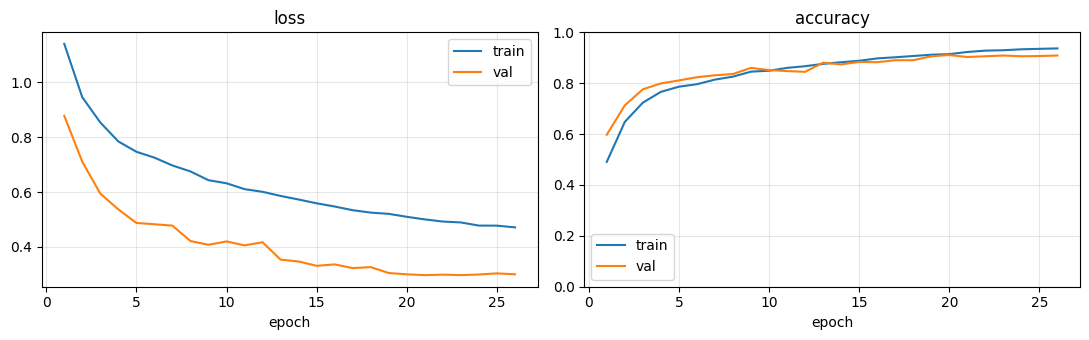

In [ ]:
import json as _json
import numpy as _np
import matplotlib.pyplot as _plt

with (RUN_DIR / 'history.json').open('r', encoding='utf-8') as f:
    history = _json.load(f)
with (RUN_DIR / 'summary.json').open('r', encoding='utf-8') as f:
    summary = _json.load(f)
print(f'best_val_acc  : {summary["best_val_acc"]*100:.2f}%  '
      f'(epoch {summary["best_epoch"]}/{summary["last_epoch_attempted"]})')
print(f'best_val_loss : {summary["best_val_loss"]:.4f}')
print(f'stop_reason   : {summary["stop_reason"]}')

ep  = _np.array([r['epoch']      for r in history])
tl  = _np.array([r['train_loss'] for r in history])
vl  = _np.array([r['val_loss']   for r in history])
ta  = _np.array([r['train_acc']  for r in history])
va  = _np.array([r['val_acc']    for r in history])

fig, axes = _plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(ep, tl, label='train'); axes[0].plot(ep, vl, label='val')
axes[0].set_title('loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, ta, label='train'); axes[1].plot(ep, va, label='val')
axes[1].set_title('accuracy'); axes[1].set_xlabel('epoch'); axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)
_plt.tight_layout(); _plt.show()


## 8. Load best checkpoint and collect predictions on the test split

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader

from videoswin.data import (
    Basketball51Dataset, VideoEval, load_splits, worker_init_fn,
    class_names_for_task, label_map_for_task, num_classes_for_task,
)
from videoswin.eval import collect_predictions
from videoswin.models import build_video_swin
from videoswin.utils import load_checkpoint

CKPT_PATH       = RUN_DIR / 'best.pt'
EVAL_REPORT_DIR = RUN_DIR / 'eval_report'
EVAL_REPORT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_SPLIT   = 'test'
EVAL_BATCH   = 4
NUM_WORKERS  = 8
USE_AMP      = True
assert CKPT_PATH.exists(), f'No best.pt at {CKPT_PATH}. Train first.'

splits = load_splits(SPLITS_JSON)
eval_samples = splits[EVAL_SPLIT]
sample_paths = [str(DATA_ROOT / Path(relative_path)) for relative_path, _ in eval_samples]

dataset = Basketball51Dataset(
    root=DATA_ROOT,
    samples=eval_samples,
    transform=VideoEval(out_h=224, out_w=224),
    num_frames=32,
    temporal_jitter=False,
)
loader = DataLoader(
    dataset,
    batch_size=EVAL_BATCH,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    worker_init_fn=worker_init_fn if NUM_WORKERS > 0 else None,
)

task_num_classes = num_classes_for_task(TASK)
task_class_names = class_names_for_task(TASK)
label_map = label_map_for_task(TASK)  # 8-class -> task label (None for 'full')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = build_video_swin(num_classes=task_num_classes, variant=VARIANT).to(device)
load_checkpoint(CKPT_PATH, model, map_location=device)
model.eval()

out = collect_predictions(model, loader, device, amp=USE_AMP, collect_features=True)
logits8_placeholder = out['logits']   # actually shape (N, task_num_classes) -- dataset labels are 8-class
labels_8            = out['labels'].astype(np.int64)
features            = out['features'].astype(np.float32)

# collect_predictions returns the dataset's raw labels (still 8-class).
# Remap them to the specialist's label space for downstream metrics.
assert label_map is not None, 'TASK must be shot or outcome in this notebook.'
labels = label_map[labels_8]

del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Softmax probabilities and argmax predictions.
def _softmax(x, axis=1):
    x = x - x.max(axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / ex.sum(axis=axis, keepdims=True)
logits = logits8_placeholder.astype(np.float32)
probs  = _softmax(logits, axis=1)
preds  = logits.argmax(axis=1)
top1   = (preds == labels).mean()

print(f'Split             : {EVAL_SPLIT}')
print(f'Samples           : {logits.shape[0]}')
print(f'Logits shape      : {logits.shape}')
print(f'Features shape    : {features.shape}')
print(f'Task top-1 acc    : {top1*100:6.2f}%   (task = {TASK}, classes = {task_class_names})')

# Cache the raw numpy arrays so the fusion notebook can reuse them without
# re-running inference.
PREDICTIONS_NPZ = EVAL_REPORT_DIR / 'raw_predictions.npz'
np.savez_compressed(
    PREDICTIONS_NPZ,
    logits=logits.astype(np.float32),
    probs=probs.astype(np.float32),
    labels=labels.astype(np.int64),
    labels_8=labels_8.astype(np.int64),
    features=features.astype(np.float32),
    sample_paths=np.array(sample_paths),
    task=np.array(TASK),
)
print(f'Cached raw predictions at {PREDICTIONS_NPZ} ({PREDICTIONS_NPZ.stat().st_size/1e6:.1f} MB)')


Downloading: "https://download.pytorch.org/models/swin3d_b_22k-7c6ae6fa.pth" to /root/.cache/torch/hub/checkpoints/swin3d_b_22k-7c6ae6fa.pth


100%|██████████| 364M/364M [00:05<00:00, 67.9MB/s]
/content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/videoswin/eval.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Split             : test
Samples           : 1032
Logits shape      : (1032, 4)
Features shape    : (1032, 1024)
Task top-1 acc    :  90.21%   (task = shot, classes = ('2p', '3p', 'ft', 'mp'))
Cached raw predictions at /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/variant_c/shot/eval_report/raw_predictions.npz (3.9 MB)


## 9. Specialist metrics

In [ ]:
# Specialist-level evaluation metrics: how well did the model learn
# *its own* task? For the Variant-C comparison against the 8-class baseline
# we then fuse these with the outcome/shot specialist; that happens in the
# outcome notebook.
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    brier_score_loss,
)

names = list(task_class_names)
K     = len(names)

acc = accuracy_score(labels, preds)
p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(
    labels, preds, average='macro', zero_division=0,
)
p_w, r_w, f_w, _ = precision_recall_fscore_support(
    labels, preds, average='weighted', zero_division=0,
)
print(f'Top-1 accuracy   : {acc*100:6.2f}%')
print(f'Macro  P/R/F1    : {p_mac*100:5.2f}% / {r_mac*100:5.2f}% / {f_mac*100:5.2f}%')
print(f'Weighted P/R/F1  : {p_w*100:5.2f}% / {r_w*100:5.2f}% / {f_w*100:5.2f}%')

print()
print('Classification report (test split):')
print(classification_report(labels, preds, target_names=names, digits=4, zero_division=0))

# Per-class accuracy (diagonal of row-normalised confusion).
cm = confusion_matrix(labels, preds, labels=list(range(K)))
cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
per_class = pd.DataFrame({
    'class'      : names,
    'support'    : cm.sum(axis=1),
    'correct'    : np.diag(cm),
    'recall'     : np.diag(cm_norm),
    'precision%' : [cm[:, c].sum() and 100.0 * cm[c, c] / cm[:, c].sum() for c in range(K)],
})
per_class['recall%'] = per_class['recall'] * 100
per_class = per_class.drop(columns=['recall'])
print()
print('Per-class summary:')
print(per_class.to_string(index=False, float_format='%.2f'))

# Brier score (only sensible for binary; for 4-way show multi-class MSE as a rough calibration proxy).
if K == 2:
    brier = brier_score_loss((labels == 1).astype(int), probs[:, 1])
    print(f'Brier score (make class)  : {brier:.4f}')
else:
    one_hot = np.eye(K)[labels]
    brier_multi = np.mean(np.sum((probs - one_hot) ** 2, axis=1))
    print(f'Multiclass Brier (avg MSE): {brier_multi:.4f}')


Top-1 accuracy   :  90.21%
Macro  P/R/F1    : 87.68% / 87.09% / 87.35%
Weighted P/R/F1  : 90.00% / 90.21% / 90.09%

Classification report (test split):
              precision    recall  f1-score   support

          2p     0.9075    0.9021    0.9048       337
          3p     0.9125    0.9456    0.9288       331
          ft     0.9913    0.9913    0.9913       229
          mp     0.6960    0.6444    0.6692       135

    accuracy                         0.9021      1032
   macro avg     0.8768    0.8709    0.8735      1032
weighted avg     0.9000    0.9021    0.9009      1032


Per-class summary:
class  support  correct  precision%  recall%
   2p      337      304       90.75    90.21
   3p      331      313       91.25    94.56
   ft      229      227       99.13    99.13
   mp      135       87       69.60    64.44
Multiclass Brier (avg MSE): 0.1484


### 9a. Confusion matrix

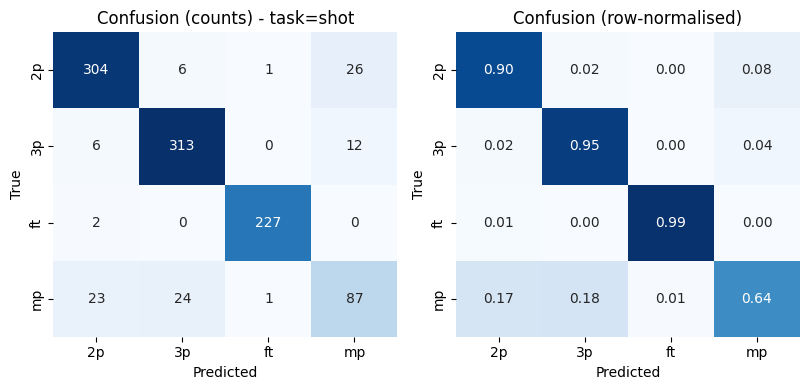

Saved /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/variant_c/shot/eval_report/confusion.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(5 + K*0.8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=names, yticklabels=names, ax=ax[0], cbar=False)
ax[0].set_title(f'Confusion')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=names, yticklabels=names, ax=ax[1], cbar=False)
ax[1].set_title('Confusion (row-normalised)')
ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('True')
plt.tight_layout()
fig.savefig(EVAL_REPORT_DIR / 'confusion.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved', EVAL_REPORT_DIR / 'confusion.png')


### 9b. Confidence distribution and reliability diagram

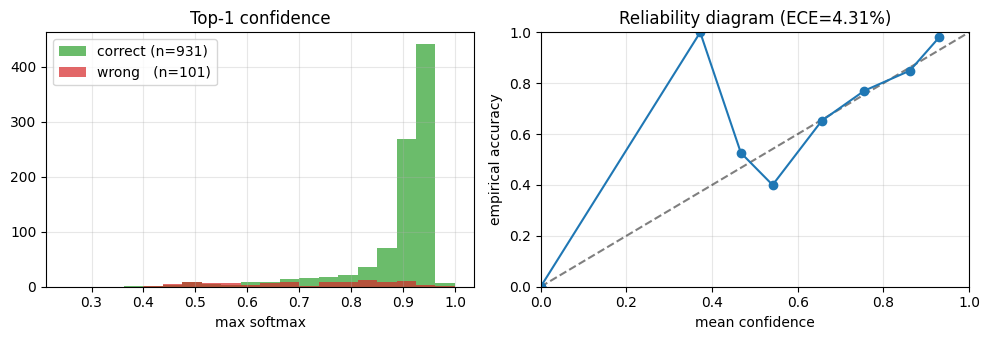

ECE (10-bin)         :   4.31%
Mean correct conf    : 0.8904
Mean wrong   conf    : 0.7173


In [ ]:
top_conf = probs.max(axis=1)
correct  = (preds == labels)

import matplotlib.pyplot as plt
bins = np.linspace(1.0 / K, 1.0, 21)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].hist(top_conf[correct],  bins=bins, alpha=0.7, label=f'correct (n={correct.sum()})', color='#2ca02c')
ax[0].hist(top_conf[~correct], bins=bins, alpha=0.7, label=f'wrong   (n={(~correct).sum()})', color='#d62728')
ax[0].set_title('Top-1 confidence'); ax[0].set_xlabel('max softmax'); ax[0].legend(); ax[0].grid(alpha=0.3)

# Reliability diagram (10 bins).
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_ids = np.clip(np.digitize(top_conf, bin_edges, right=True) - 1, 0, n_bins - 1)
acc_per_bin  = np.zeros(n_bins)
conf_per_bin = np.zeros(n_bins)
count_per_bin = np.zeros(n_bins)
for b in range(n_bins):
    mask = bin_ids == b
    if mask.any():
        acc_per_bin[b]  = correct[mask].mean()
        conf_per_bin[b] = top_conf[mask].mean()
        count_per_bin[b] = mask.sum()

ece = float(np.sum(count_per_bin * np.abs(acc_per_bin - conf_per_bin)) / max(1, count_per_bin.sum()))
ax[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax[1].plot(conf_per_bin, acc_per_bin, 'o-', color='#1f77b4')
ax[1].set_xlim(0, 1); ax[1].set_ylim(0, 1)
ax[1].set_title(f'Reliability diagram (ECE={ece*100:.2f}%)')
ax[1].set_xlabel('mean confidence'); ax[1].set_ylabel('empirical accuracy')
ax[1].grid(alpha=0.3)
plt.tight_layout()
fig.savefig(EVAL_REPORT_DIR / 'confidence.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'ECE (10-bin)         : {ece*100:6.2f}%')
print(f'Mean correct conf    : {top_conf[correct].mean():6.4f}')
print(f'Mean wrong   conf    : {top_conf[~correct].mean():6.4f}')
